# Inhalt aus: `B510-cv-dt-titanic.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Cross Validation - Decision Tree - Titanic
</b></font> </br></p>

---


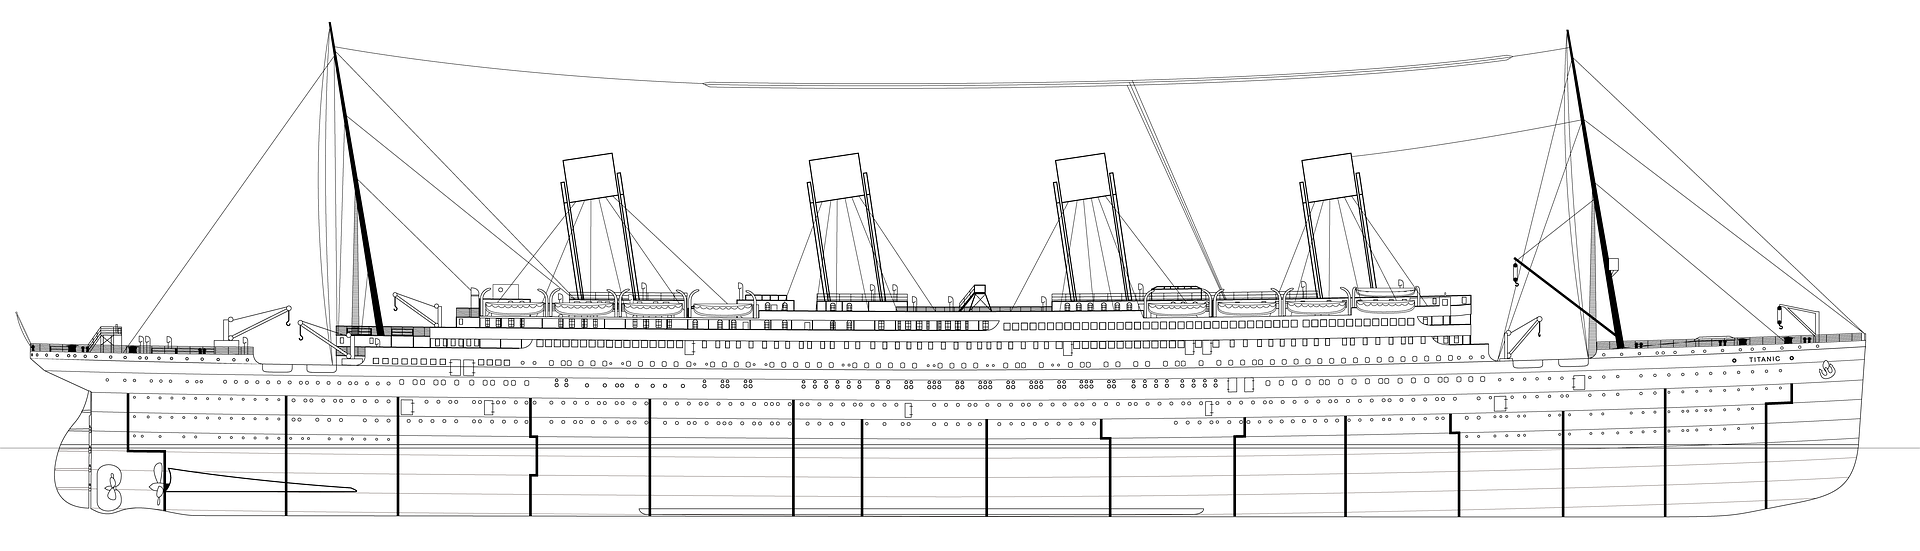

Bild von <a href="https://pixabay.com/de/users/axonia-14892766/?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=6068711">axonia</a> auf <a href="https://pixabay.com/de//?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=6068711">Pixabay</a>

# 0  | Install & Import
***

In [ ]:
# Install

In [ ]:
# Import
from pandas import read_csv, DataFrame
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import Ordinalcoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
    StratifiedKFold,
    KFold,
    LeaveOneOut,
    cross_validate
)
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

import plotly.express as px
import plotly.subplots as sp

In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings("ignore")

# 1  | Understand
***


<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

<p><font color='black' size="5">
📒 Anwendungsfall
</font></p>

Dies ist der legendäre Titanic ML-Wettbewerb – die beste erste Herausforderung, um in ML-Modellierung einzutauchen.

Die Aufgabe ist einfach: Verwenden Sie maschinelles Lernen, um ein Modell zu erstellen, das vorhersagt, welche Passagiere den Schiffbruch der Titanic überlebt haben.

[Titanic Org](https://www.encyclopedia-titanica.org/)

[DataSet](https://www.openml.org/search?type=data&status=active&id=41265)

[Info](https://www.kaggle.com/competitions/titanic/data)



**Datenfelder:**   
+ Age: Alter
+ Fare: Ticketpreis
+ Sex: Geschlecht (0 = männlich, 1 = weiblich)
+ sibsp: Der Datensatz definiert Familienbeziehungen auf diese Weise ... Geschwister = Bruder, Schwester, Stiefbruder, Stiefschwester Ehepartner = Ehemann, Ehefrau (Geliebte und Verlobte wurden ignoriert)
+ parch: Der Datensatz definiert Familienbeziehungen auf diese Weise ... Elternteil = Mutter, Vater Kind = Tochter, Sohn, Stieftochter, Stiefsohn. Einige Kinder reisten nur mit einem Kindermädchen, daher ist für sie Parch=0
+ Pclass: Passagierklasse, 1.- 3. Klasse
+ Embarked: Hafen der Einschiffung

In [ ]:
df = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/Titanic.csv",
    usecols=["pclass", "survived", "sex", "age", "sibsp", "parch"],
)

In [ ]:
data = df.copy()
target = data.pop("survived")

<p><font color='black' size="5">
🔎 EDA (Exploratory Data Analysis) mit Pandas
</font></p>

In [ ]:
data.info()

In [ ]:
data.describe().T

In [ ]:
data.groupby("sex").count()

In [ ]:
target.value_counts()

# **2 | Prepare**

---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Duplikate ermitteln/löschen</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features Kodieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>
✅ Train-Test-Split durchführen</br>

<p><font color='black' size="5">
Datentyp ermitteln
</font></p>

In [ ]:
all_col = data.columns
num_col = data.select_dtypes(include="number").columns
cat_col = data.select_dtypes(exclude="number").columns

<p><font color='black' size="5">
Missing Values
</font></p>

In [ ]:
mv = data.isnull().sum()
mv_col = list(mv[mv > 0].index)

In [ ]:
imputer = SimpleImputer(missing_values=np.nan, strategy="most_frequent")
data[mv_col] = DataFrame(imputer.fit_transform(data[mv_col]))

<p><font color='black' size="5">
Kodierung
</font></p>

In [ ]:
coder = Ordinalcoder()
data[cat_col] = coder.fit_transform(data[cat_col])

<p><font color='black' size="5">
Skalierung
</font></p>

In [ ]:
scaler = MinMaxScaler()
data[num_col] = scaler.fit_transform(data[num_col])

<p><font color='black' size="5">
✂️ Train-Test-Split
</font></p>


In [ ]:
data_train, data_test, target_train, target_test = train_test_split(
    data, target, test_size=0.20, random_state=42, stratify=target
)
data_train.shape, data_test.shape, target_train.shape, target_test.shape

# **3 | Modeling**
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Validiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

<p><font color='black' size="5">
🏃 Modellauswahl & Training
</font></p>

In [ ]:
model = DecisionTreeClassifier(max_depth=3)

In [ ]:
model.fit(data_train, target_train)

# 4 | Evaluate
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>

<p><font color='black' size="5">
🔭 Prognose
</font></p>

In [ ]:
target_train_pred = model.predict(data_train)
target_test_pred = model.predict(data_test)

<p><font color='black' size="5">
📱 Confusion Matrix
</font></p>

In [ ]:
conf_matrix = confusion_matrix(target_test, target_test_pred)
display_labels_ = ["Not Survived", "Survived"]
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=display_labels_)
disp.plot(cmap="Blues")

In [ ]:
print(
    classification_report(target_test, target_test_pred, target_names=display_labels_)
)

<p><font color='black' size="5">
🎯 Accuracy
</font></p>

In [ ]:
acc_train = accuracy_score(target_train, target_train_pred) * 100
print(f"Modell: {model} -- Train -- Accuracy: {acc_train:5.2f}")

In [ ]:
acc_test = accuracy_score(target_test, target_test_pred) * 100
print(f"Modell: {model} -- Test -- Accuracy: {acc_test:5.2f}%")

<p><font size="5">
✨ Feature Importance
</p>

In [ ]:
title_ = "Feature Importance Titanic"
px.bar(
    x=model.feature_importances_, y=data.columns, title=title_, width=800, height=600
).update_yaxes(categoryorder="total ascending")

<p><font size="5">
❌ Cross-Validation - K-Fold
</p>



In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
cv_results = cross_validate(
    model,
    data_train,
    target_train,
    scoring="accuracy",
    cv=cv,
    return_train_score=True,
    return_estimator=True,
)

In [ ]:
cv_results

In [ ]:
train_result = cv_results["train_score"].mean()
val_result = cv_results["test_score"].mean()
print(f"Train {train_result:.2f} -- Validation {val_result:.2f}")

<p><font size="5">
🪂 Datensätze der einzelnen Kreuzvalidierungen
</p>

In [ ]:
cv.get_n_splits(data_train)
print(cv)

for i, (train_index, val_index) in enumerate(cv.split(data_train, target_train)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index[:10]}, count: {len(train_index):,.0f}")
    print(f"  Test:  index={val_index[:10]}, count: {len(val_index):,.0f}")

# 5 | Deploy
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>

# Inhalt aus: `B515-cv-dt-diamonds.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Cross Validation - Decision Tree - Diamonds
</b></font> </br></p>

---

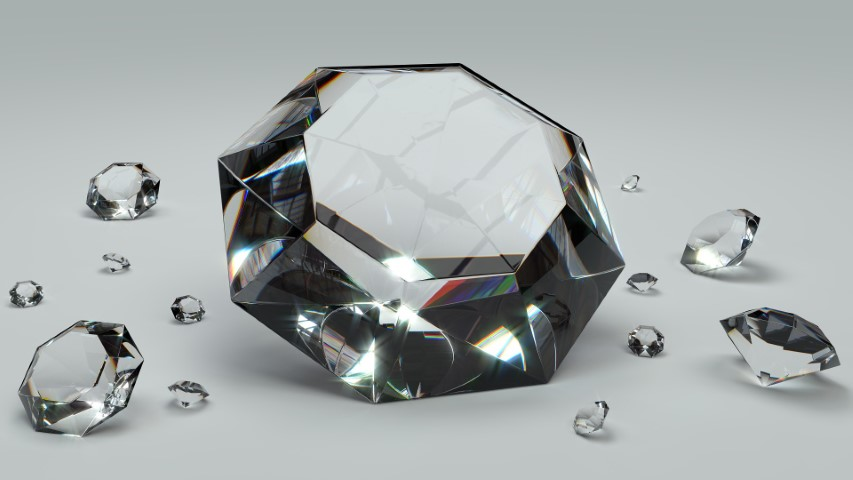

Bild von <a href="https://pixabay.com/de/users/colin00b-346653/?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=1186139">Colin Behrens</a> auf <a href="https://pixabay.com/de//?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=1186139">Pixabay</a>

# 0  | Install & Import
***

In [ ]:
# Install

In [ ]:
# Import
from pandas import read_csv, DataFrame

from sklearn.preprocessing import Ordinalcoder
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error

import plotly.express as px
import plotly.subplots as sp

In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings("ignore")

# **1 | Understand**
***


<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

<p><font color='black' size="5">
Anwendungsfall
</font></p>

---

Dieser klassische Datensatz enthält die Preise und andere Attribute von fast 54.000 Diamanten.



[DataSet](https://www.openml.org/search?type=data&status=active&id=42225)

[Info](https://www.kaggle.com/datasets/shivam2503/diamonds)


In [ ]:
df = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/diamonds.csv",
    usecols=[
        "carat",
        "cut",
        "color",
        "clarity",
        "depth",
        "table",
        "price",
    ],
)

In [ ]:
data = df.copy()
target = data.pop("price")

<p><font color='black' size="5">
EDA (Exploratory Data Analysis) mit Pandas
</font></p>

In [ ]:
data.info()

In [ ]:
data.describe().T

In [ ]:
data.groupby("cut").count()

In [ ]:
data.groupby("color").count()

<p><font color='black' size="5">
EDA (Exploratory Data Analysis) mit Plotly
</font></p>

In [ ]:
title_ = "Depth"
b1 = px.box(data["depth"], title=title_, width=600, height=600)

title_ = "Carat"
b2 = px.box(data["carat"], title=title_, width=600, height=600)

title_ = "Table"
b3 = px.box(data["table"], title=title_, width=600, height=600)

fig = sp.make_subplots(rows=1, cols=3, subplot_titles=("Depth", "Carat", "Table"))

for trace in b1.data:
    fig.add_trace(trace, row=1, col=1)

for trace in b2.data:
    fig.add_trace(trace, row=1, col=2)

for trace in b3.data:
    fig.add_trace(trace, row=1, col=3)

# Layout anpassen
fig.update_layout(width=1000, height=500, title_text="Box-Plots")

# Plot anzeigen
fig.show()

# 2 |  Prepare

---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Train-Test-Split durchführen</br>
✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features Kodieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>

<p><font color='black' size="5">
Datentyp ermitteln
</font></p>

In [ ]:
all_col = data.columns
num_col = data.select_dtypes(include="number").columns
cat_col = data.select_dtypes(exclude="number").columns

<p><font color='black' size="5">
Kodierung
</font></p>

In [ ]:
cat_seq = [
    ["Fair", "Good", "Very Good", "Premium", "Ideal"],
    ["J", "I", "H", "G", "F", "E", "D"],
    ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"],
]
coder = Ordinalcoder(categories=cat_seq)
data[cat_col] = coder.fit_transform(data[cat_col])

<p><font size="5">
Train-Test-Split
</p>

In [ ]:
data_train, data_test, target_train, target_test = train_test_split(
    data, target, test_size=0.30, random_state=42
)
data_train.shape, data_test.shape, target_train.shape, target_test.shape

# **3 | Modeling**
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Validiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

<p><font size="5">
Modelauswahl
</p>

In [ ]:
model = DecisionTreeRegressor(max_depth=4)

<p><font size="5">
Training
</p>

In [ ]:
model.fit(data_train, target_train)

# 4 | Evaluate
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>

<p><font color='black' size="5">
Prognose
</font></p>

In [ ]:
target_train_pred = model.predict(data_train)
target_test_pred = model.predict(data_test)


<p><font color='black' size="5">
Bestimmtheitsmass
</font></p>


In [ ]:
r2_train = r2_score(target_train, target_train_pred)
print(f"Modell: {model}\n -- Train --- Bestimmtheitsmass: {r2_train:5.2f}")

In [ ]:
r2_test = r2_score(target_test, target_test_pred)
print(f"Modell: {model}\n -- Test --- Bestimmtheitsmass: {r2_test:5.2f}")


<p><font color='black' size="5">
Feature Importance
</font></p>

In [ ]:
px.bar(x=model.feature_importances_, y=data.columns).update_yaxes(
    categoryorder="total ascending"
)

<p><font size="5">
Cross-Validation - K-Fold
</p>



In [ ]:
cv = KFold(n_splits=3, shuffle=True, random_state=42)

In [ ]:
cv_results = cross_validate(
    model,
    data_train,
    target_train,
    scoring="r2",
    cv=cv,
    return_train_score=True,
    return_estimator=True,
)

In [ ]:
cv_results

In [ ]:
train_result = cv_results["train_score"].mean()
val_result = cv_results["test_score"].mean()
print(f"Train {train_result:.2f} -- Validation {val_result:.2f}")

<p><font size="5">
Datensätze der einzelnen Kreuzvalidierungen
</p>

In [ ]:
cv.get_n_splits(data_train)
print(cv)

for i, (train_index, val_index) in enumerate(cv.split(data_train)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}, count: {len(train_index):,.0f}")
    print(f"  Test:  index={val_index}, count: {len(val_index):,.0f}")

# 5 | Deploy
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>

# Inhalt aus: `B520-bootstrapping-dt-titanic.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Bootstrapping - Decision Tree - Titanic
</b></font> </br></p>

---


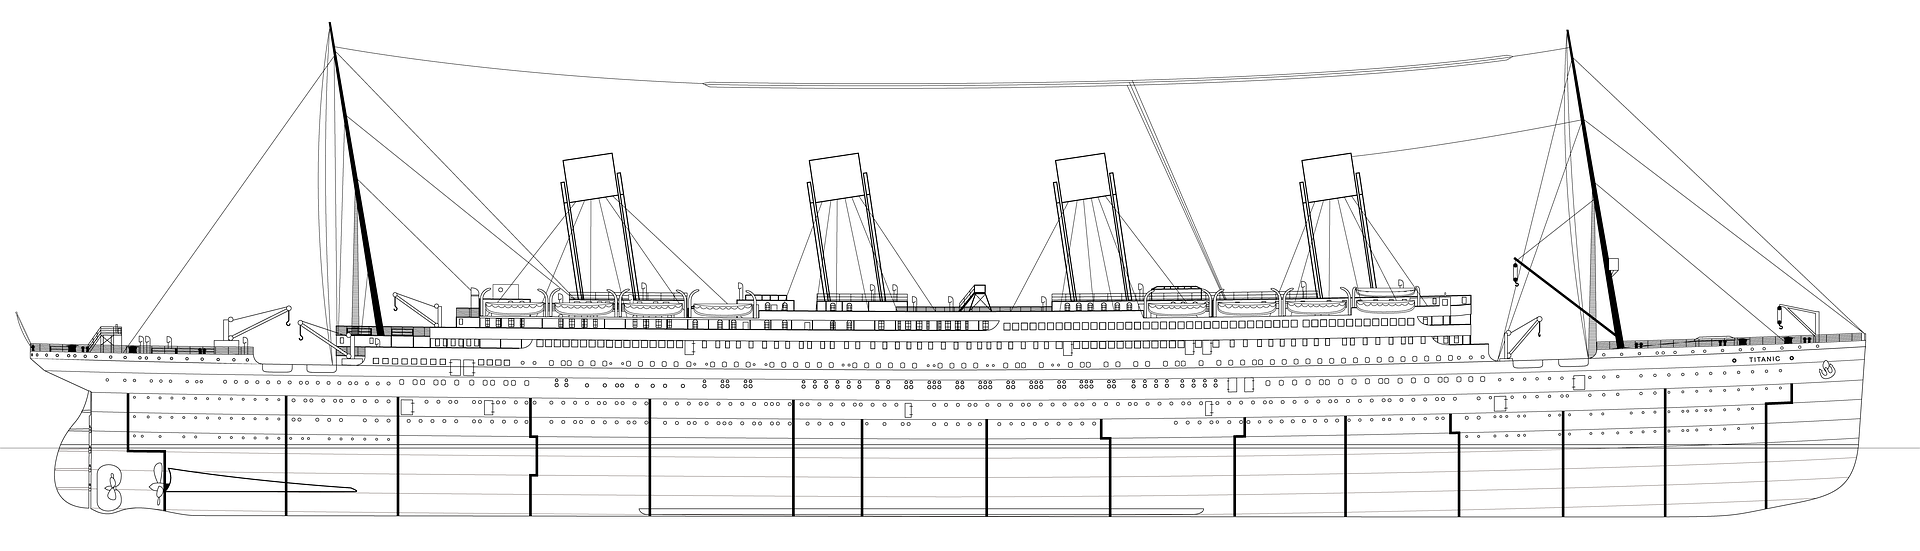

Bild von <a href="https://pixabay.com/de/users/axonia-14892766/?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=6068711">axonia</a> auf <a href="https://pixabay.com/de//?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=6068711">Pixabay</a>

# 0  | Install & Import
***

In [ ]:
# Install

In [ ]:
# Import
from pandas import read_csv, DataFrame
from numpy.random import choice
from numpy import array, nan, percentile, mean

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import Ordinalcoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

import plotly.express as px
import plotly.subplots as sp

In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings("ignore")

# 1  | Understand
***


<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

<p><font color='black' size="5">
📒 Anwendungsfall
</font></p>

Dies ist der legendäre Titanic ML-Wettbewerb – die beste erste Herausforderung, um in ML-Modellierung einzutauchen.

Die Aufgabe ist einfach: Verwenden Sie maschinelles Lernen, um ein Modell zu erstellen, das vorhersagt, welche Passagiere den Schiffbruch der Titanic überlebt haben.

[Titanic Org](https://www.encyclopedia-titanica.org/)

[DataSet](https://www.openml.org/search?type=data&status=active&id=41265)

[Info](https://www.kaggle.com/competitions/titanic/data)



**Datenfelder:**   
+ Age: Alter
+ Fare: Ticketpreis
+ Sex: Geschlecht (0 = männlich, 1 = weiblich)
+ sibsp: Der Datensatz definiert Familienbeziehungen auf diese Weise ... Geschwister = Bruder, Schwester, Stiefbruder, Stiefschwester Ehepartner = Ehemann, Ehefrau (Geliebte und Verlobte wurden ignoriert)
+ parch: Der Datensatz definiert Familienbeziehungen auf diese Weise ... Elternteil = Mutter, Vater Kind = Tochter, Sohn, Stieftochter, Stiefsohn. Einige Kinder reisten nur mit einem Kindermädchen, daher ist für sie Parch=0
+ Pclass: Passagierklasse, 1.- 3. Klasse
+ Embarked: Hafen der Einschiffung

In [ ]:
df = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/Titanic.csv",
    usecols=["pclass", "survived", "sex", "age", "sibsp", "parch"],
)

In [ ]:
data = df.copy()
target = data.pop("survived")

<p><font color='black' size="5">
🔎 EDA (Exploratory Data Analysis) mit Pandas
</font></p>

In [ ]:
data.info()

In [ ]:
data.describe().T

In [ ]:
data.groupby("sex").count()

In [ ]:
target.value_counts()

# **2 | Prepare**

---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Duplikate ermitteln/löschen</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features Kodieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>
✅ Train-Test-Split durchführen</br>

<p><font color='black' size="5">
Datentyp ermitteln
</font></p>

In [ ]:
all_col = data.columns
num_col = data.select_dtypes(include="number").columns
cat_col = data.select_dtypes(exclude="number").columns

<p><font color='black' size="5">
Missing Values
</font></p>

In [ ]:
mv = data.isnull().sum()
mv_col = list(mv[mv > 0].index)

In [ ]:
imputer = SimpleImputer(missing_values=nan, strategy="most_frequent")
data[mv_col] = DataFrame(imputer.fit_transform(data[mv_col]))

<p><font color='black' size="5">
Kodierung
</font></p>

In [ ]:
coder = Ordinalcoder()
data[cat_col] = coder.fit_transform(data[cat_col])

<p><font color='black' size="5">
Skalierung
</font></p>

In [ ]:
scaler = MinMaxScaler()
data[num_col] = scaler.fit_transform(data[num_col])

<p><font color='black' size="5">
✂️ Train-Test-Split
</font></p>


In [ ]:
data_train, data_test, target_train, target_test = train_test_split(
    data, target, test_size=0.20, random_state=42, stratify=target
)
data_train.shape, data_test.shape, target_train.shape, target_test.shape

# **3 | Modeling**
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Validiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

<p><font color='black' size="5">
🏃 Modellauswahl & Training
</font></p>

In [ ]:
model = DecisionTreeClassifier(max_depth=3)

In [ ]:
model.fit(data_train, target_train)

# 4 | Evaluate
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>

<p><font color='black' size="5">
🔭 Prognose
</font></p>

In [ ]:
target_train_pred = model.predict(data_train)
target_test_pred = model.predict(data_test)

<p><font color='black' size="5">
📱 Confusion Matrix
</font></p>

In [ ]:
conf_matrix = confusion_matrix(target_test, target_test_pred)
display_labels_ = ["Not Survived", "Survived"]
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=display_labels_)
disp.plot(cmap="Blues")

In [ ]:
print(classification_report(target_test, target_test_pred, target_names=display_labels_))

<p><font color='black' size="5">
🎯 Accuracy
</font></p>

In [ ]:
acc_train = accuracy_score(target_train, target_train_pred) * 100
print(f"Modell: {model} -- Train -- Accuracy: {acc_train:5.2f}")

In [ ]:
acc_test = accuracy_score(target_test, target_test_pred) * 100
print(f"Modell: {model} -- Test -- Accuracy: {acc_test:5.2f}%")

<p><font size="5">
✨ Feature Importance
</p>

In [ ]:
title_ = "Feature Importance Titanic"
px.bar(
    x=model.feature_importances_, y=data.columns, title=title_, width=800, height=600
).update_yaxes(categoryorder="total ascending")

<p><font size="5">
👢 Bootstrapping
</p>



In [ ]:
n_bootstrap_samples = 1000  # Empfehlung ist 1000!
bootstrap_accuracy = []

In [ ]:
# Schleife für Anzahl der Bootstrap-Samples
for j in range(n_bootstrap_samples):
    # Bootstrap-Stichprobe mit Zurücklegen ziehen
    bootstrap_indices = choice(len(data), size=len(data), replace=True)

    # Effiziente OOB-Ermittlung über Set-Operationen
    bootstrap_set = set(bootstrap_indices)
    oob_indices = array([i for i in range(len(data)) if i not in bootstrap_set])

    # Bootstrap- und OOB-Daten erstellen
    data_bootstrap = data.iloc[bootstrap_indices]  # iloc ist sicherer als loc
    target_bootstrap = target.iloc[bootstrap_indices]
    data_oob = data.iloc[oob_indices]
    target_oob = target.iloc[oob_indices]

    # Modell trainieren und bewerten
    model.fit(data_bootstrap, target_bootstrap)
    target_oob_pred = model.predict(data_oob)
    accuracy = accuracy_score(target_oob, target_oob_pred)
    bootstrap_accuracy.append(accuracy)

    # Fortschrittsanzeige
    if j % 100 == 0:
        print(f"Sample: {j:>7,.0f}   Train: {len(bootstrap_indices):>7,.0f}    OOB: {len(oob_indices):>7,.0f}")

<p><font color='black' size="5">
Konfidenzintervall
</font></p>

Ein Konfidenzintervall ist ein Bereich, der angibt, in welchem Wertebereich ein unbekannter Parameter (z. B. Mittelwert, Genauigkeit, ...) mit einer bestimmten Wahrscheinlichkeit liegt.

**Einfach:**    
Ein Konfidenzintervall sagt: "Wir sind ziemlich sicher, dass der wahre Wert irgendwo in diesem Bereich liegt."

In [ ]:
# Berechnung des mittleren Accuracy und des Konfidenzintervalls
mean_accuracy = mean(bootstrap_accuracy)
conf_interval_80 = percentile(bootstrap_accuracy, [10, 90])
conf_interval_95 = percentile(bootstrap_accuracy, [2.5, 97.5])
conf_interval_99 = percentile(bootstrap_accuracy, [0.5, 0.5])

In [ ]:
print(f"Mittlerer Accuracy: {mean_accuracy:.4f}")
print("Konfidenzintervall Accuracy:")
print(f"80% KI/CI: [{conf_interval_80[0]:.4f},  {conf_interval_80[1]:.4f}]")
print(f"95% KI/CI: [{conf_interval_95[0]:.4f},  {conf_interval_95[1]:.4f}]")
print(f"99% KI/CI: [{conf_interval_99[0]:.4f},  {conf_interval_99[1]:.4f}]")

In [ ]:
fig = px.histogram(
    bootstrap_accuracy,
    nbins=50,
    title="Verteilung der Bootstrap Accuracy (95% Konfidenzintervall)",
    labels={"value": "Accuracy"},
    width=1000, # Breite der Grafik
    height=600, # Höhe der Grafik
)
fig.add_vline(
    x=conf_interval_95[0],
    line_dash="dash",
    line_color="red",
    annotation_text=f"95% CI Lower: {conf_interval_95[0]:.4f}",
    annotation_position="top left",
)
fig.add_vline(
    x=conf_interval_95[1],
    line_dash="dash",
    line_color="red",
    annotation_text=f"95% CI Upper: {conf_interval_95[1]:.4f}",
    annotation_position="top right",
)
fig.show()

# 5 | Deploy
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>

# Inhalt aus: `B530-GridSearch-nn-mlp-cancer.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
GridSearch - Neural Network - MLPClassifier - Cancer
</b></font> </br></p>

---


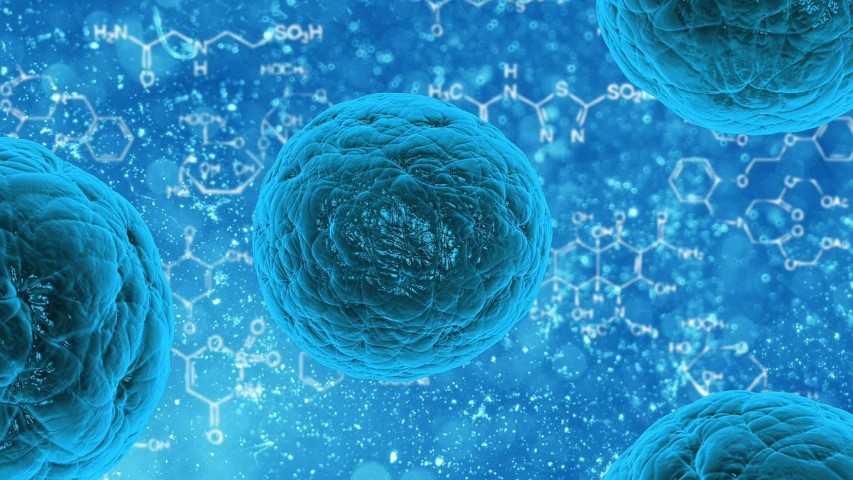

Bild von <a href="https://pixabay.com/de/users/publicdomainpictures-14/?utm_source=link-attribution&utm_medium=referral&utm_campaign=image&utm_content=163711">PublicDomainPictures</a> auf <a href="https://pixabay.com/de//?utm_source=link-attribution&utm_medium=referral&utm_campaign=image&utm_content=163711">Pixabay</a>

# 0  | Install & Import
***

In [ ]:
# Install


In [ ]:
# Import
from pandas import read_csv, DataFrame

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

import plotly.express as px
import plotly.subplots as sp

In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings("ignore")

# **1 | Understand**
---


<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

<p><font color='black' size="5">
📒 Anwendungsfall
</font></p>




**Beschreibung:**   
Diese Arbeit entstand aus dem Wunsch, Gewebeproben ausschließlich auf der Grundlage einer Feinnadelpunktion (FNA) genau zu diagnostizieren. In Zusammenarbeit mit Prof. Mangasarian und zwei seiner Doktoranden, Rudy Setiono und Kristin Bennett , wurde mithilfe der Multisurface-Methode (MSM) zur Mustertrennung dieser neun Merkmale ein Klassifikator erstellt, der 97 % der neuen Fälle erfolgreich diagnostizierte. Der resultierende Datensatz ist als Wisconsin Breast Cancer Data bekannt.


Die Arbeit an der Bildanalyse begann 1990 mit der Aufnahme von Nick Street in das Forschungsteam. Ziel war es, die Probe anhand eines digitalen Bildes eines kleinen Abschnitts des FNA-Objektträgers zu diagnostizieren.

**Diagnoseablauf:**

Es wird aus dem Gewebe eine FNA entnommen. Dieses Material wird dann auf einen Objektträger montiert und gefärbt, um die Zellkerne hervorzuheben. Ein Teil des Objektträgers, in dem die Zellen gut differenziert sind, wird dann mit einer Digitalkamera und einem Framegrabber-Board gescannt.
Anschließend isoliert der Anwender die einzelnen Zellkerne . Mit einem Mauszeiger zeichnet der Benutzer die ungefähre Grenze jedes Kerns. Mithilfe eines Computer-Vision-Ansatzes, konvergieren diese Annäherungen dann an die genauen nuklearen Grenzen. Sobald alle (oder die meisten) Kerne auf diese Weise isoliert wurden, berechnet das Programm Werte für jedes der zehn Merkmale jedes Kerns und misst Größe, Form und Textur. Der Mittelwert, der Standardfehler und die Extremwerte dieser Merkmale werden berechnet, was zu insgesamt 30 Kernmerkmalen für jede Probe führt.

[DataSet](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original)

[Info](https://pages.cs.wisc.edu/~olvi/uwmp/cancer.html)

**Wertebereich: 1 – 10**      
+ 1 = eher unauffällig / typisch gutartig        

+ 10 = stark auffällig / typisch bösartig



**Features:**


+ Dicke: 1 - 10
+ Einheitlichkeit der Zellgröße: 1 - 10
+ Gleichmäßigkeit der Zellform: 1 - 10
+ Randhaftung: 1 - 10
+ Größe einzelner Epithelzellen: 1 - 10
+ Nackte Kerne: 1 - 10
+ Blandes Chromatin: 1 - 10
+ Normale Nukleolen: 1 - 10
+ Mitosen: 1 - 10

**Klassen:**

+ Klasse: (2 für gutartig, 4 für bösartig)

**Kurzerläuterung:**

| **Merkmal**                           | **Erläuterung (einfach und verständlich)**                                                                            |
| ------------------------------------- | --------------------------------------------------------------------------------------------------------------------- |
| **Dicke** *(Clump Thickness)*         | Wie dick oder dicht gepackt die Zellverbände sind – dicker = potenziell auffälliger                                   |
| **Einheitlichkeit der Zellgröße**     | Wie ähnlich oder unterschiedlich die Zellgrößen sind – starke Unterschiede können auf Bösartigkeit hinweisen          |
| **Gleichmäßigkeit der Zellform**      | Wie regelmäßig die Zellformen sind – unregelmäßige Formen sind oft verdächtig                                         |
| **Randhaftung** *(Marginal Adhesion)* | Wie gut haften die Zellen aneinander – geringe Haftung kann auf bösartige Zellen hindeuten                            |
| **Größe einzelner Epithelzellen**     | Durchschnittliche Größe bestimmter Zellen – ungewöhnlich große Zellen können ein Risikozeichen sein                   |
| **Nackte Kerne** *(Bare Nuclei)*      | Zellkerne, die außerhalb von Zellen sichtbar sind – in größerer Zahl ein typisches Merkmal bösartiger Tumoren         |
| **Blandes Chromatin**                 | Wie gleichmäßig die DNA-Struktur im Zellkern aussieht – „bland“ heißt einheitlich, Abweichungen können auffällig sein |
| **Normale Nukleolen**                 | Nukleolen = Zellkernbestandteile – viele oder große Nukleolen sind oft in bösartigen Zellen zu finden                 |
| **Mitosen**                           | Zellteilungen – viele Mitosen deuten auf schnelles Zellwachstum hin, was ein Warnzeichen sein kann                    |


In [ ]:
import pandas as pd
df = read_csv('https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/breast_cancer_wisconsin.csv')

In [ ]:
data = df.copy()
target = data.pop("Class")

# **2 | Prepare**

---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Duplikate ermitteln/löschen</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features Kodieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>
✅ Train-Test-Split durchführen</br>

<p><font color='black' size="5">
Datentyp
</font></p>

In [ ]:
all_col = data.columns
num_col = data.select_dtypes(include="number").columns
cat_col = data.select_dtypes(exclude="number").columns

<p><font color='black' size="5">
Missing Values
</font></p>

In [ ]:
data = data.dropna()

In [ ]:
target = target.loc[data.index]

<p><font color='black' size="5">
Kodieren Target auf 0/1
</font></p>

In [ ]:
target.replace([2, 4], [0, 1], inplace=True)

<p><font color='black' size="5">
Skalieren
</font></p>

In [ ]:
scaler = MinMaxScaler()
data[num_col] = scaler.fit_transform(data[num_col])

<p><font color='black' size="5">
Train-Test-Split
</font></p>


In [ ]:
data_train, data_test, target_train, target_test = train_test_split(
    data, target, test_size=0.3, random_state=42, stratify=target
)
data_train.shape, data_test.shape, target_train.shape, target_test.shape

# **3 | Modeling**
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Validiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

 <p><font color='black' size="5">
Modellauswahl & Training
</font></p>

In [ ]:
model = MLPClassifier(random_state = 42)

<p><font color='black' size="5">
Hyperparameter Tuning - GridSearch
</font></p>

In [ ]:
parameter_grid = {}
parameter_grid["hidden_layer_sizes"] = [(10, 10, 10), 50, 100]
parameter_grid["learning_rate"] = ["constant", "adaptive"]
parameter_grid["max_iter"] = [100, 200, 300]

In [ ]:
tuned_model = GridSearchCV(
    model,
    parameter_grid,
    cv=2,
    scoring=["accuracy"],
    refit="accuracy",
    n_jobs=4,
    return_train_score=True,
    verbose=2,
)

In [ ]:
tuned_model.fit(data_train, target_train)
print("Score: ", tuned_model.best_score_)
print("Parameters: ", tuned_model.best_params_)

<p><font color='black' size="5">
Alle Ergebnisse GridSearch
</font></p>

In [ ]:
tuned_model.cv_results_.keys()

<p><font color='black' size="5">
Ergebnisse je Parameter Mix
</font></p>

In [ ]:
tuned_model.best_estimator_

In [ ]:
tuned_model.best_params_

In [ ]:
tuned_model.best_score_

In [ ]:
# Erstellen eines DataFrame direkt aus den relevanten Teilen des Dictionaries
results = DataFrame(
    {
        "MTA": tuned_model.cv_results_["mean_test_accuracy"],
        "Parameter": tuned_model.cv_results_["params"],
    }
)
results

# 4 | Evaluate
---


<p><font color='black' size="5">
Prognose auf Basis des besten Modells
</font></p>

In [ ]:
target_train_pred = tuned_model.predict(data_train)
target_test_pred = tuned_model.predict(data_test)

In [ ]:
tuned_model.get_params(deep=False)

<p><font color='black' size="5">
Accuracy
</font></p>

In [ ]:
acc = tuned_model.score(data_train, target_train) * 100
print(f"Accuracy: {acc:5.2f}%")

In [ ]:
acc = tuned_model.score(data_test, target_test) * 100
print(f"Accuracy: {acc:5.2f}%")

# 5 | Deploy
---


# Inhalt aus: `B550-RandomizedSearch-rf-diamonds.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
RandomizedSearch - Random Forest - Diamonds
</b></font> </br></p>

---


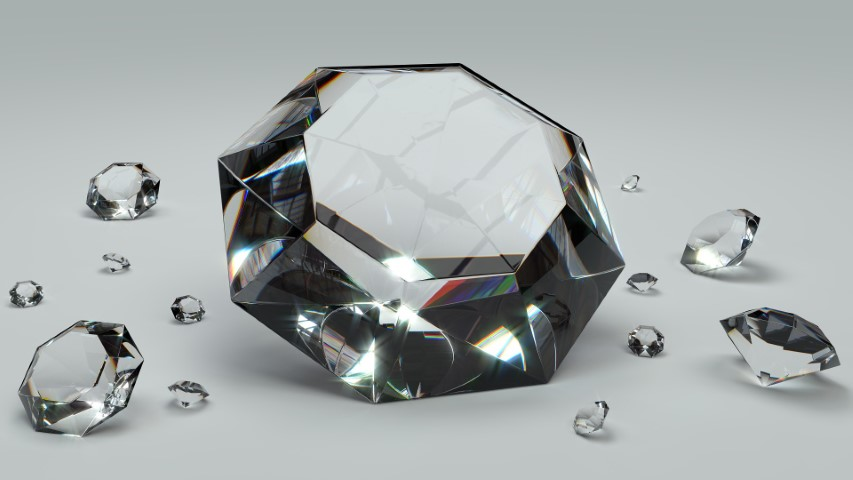

Bild von <a href="https://pixabay.com/de/users/colin00b-346653/?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=1186139">Colin Behrens</a> auf <a href="https://pixabay.com/de//?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=1186139">Pixabay</a>

# 0  | Install & Import
***

In [ ]:
# Install

In [ ]:
# Import
from pandas import read_csv, DataFrame
import numpy as np

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import Ordinalcoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

import plotly.express as px
import plotly.subplots as sp

In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings("ignore")

# **1 | Understand**
***


<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

<p><font color='black' size="5">
Anwendungsfall
</font></p>

---

Dieser klassische Datensatz enthält die Preise und andere Attribute von fast 54.000 Diamanten.



[DataSet](https://www.openml.org/search?type=data&status=active&id=42225)

[Info](https://www.kaggle.com/datasets/shivam2503/diamonds)


In [ ]:
df = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/diamonds.csv",
    usecols=[
        "carat",
        "cut",
        "color",
        "clarity",
        "depth",
        "table",
        "price",
    ],
)

In [ ]:
data = df.copy()
target = data.pop("price")

<p><font color='black' size="5">
EDA (Exploratory Data Analysis) mit Pandas
</font></p>

In [ ]:
data.info()

In [ ]:
data.describe().T

In [ ]:
data.groupby("cut").count()

In [ ]:
data.groupby("color").count()

<p><font color='black' size="5">
EDA (Exploratory Data Analysis) mit Plotly
</font></p>

In [ ]:
title_ = "Depth"
b1 = px.box(data["depth"], title=title_, width=600, height=600)

title_ = "Carat"
b2 = px.box(data["carat"], title=title_, width=600, height=600)

title_ = "Table"
b3 = px.box(data["table"], title=title_, width=600, height=600)

fig = sp.make_subplots(rows=1, cols=3, subplot_titles=("Depth", "Carat", "Table"))

for trace in b1.data:
    fig.add_trace(trace, row=1, col=1)

for trace in b2.data:
    fig.add_trace(trace, row=1, col=2)

for trace in b3.data:
    fig.add_trace(trace, row=1, col=3)

# Layout anpassen
fig.update_layout(width=1000, height=500, title_text="Box-Plots")

# Plot anzeigen
fig.show()

# 2 |  Prepare

---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Train-Test-Split durchführen</br>
✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features Kodieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>

<p><font color='black' size="5">
Datentyp ermitteln
</font></p>

In [ ]:
all_col = data.columns
num_col = data.select_dtypes(include="number").columns
cat_col = data.select_dtypes(exclude="number").columns

<p><font color='black' size="5">
Kodierung
</font></p>

In [ ]:
cat_seq = [
    ["Fair", "Good", "Very Good", "Premium", "Ideal"],
    ["J", "I", "H", "G", "F", "E", "D"],
    ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"],
]
coder = Ordinalcoder(categories=cat_seq)
data[cat_col] = coder.fit_transform(data[cat_col])

<p><font size="5">
Train-Test-Split
</p>

In [ ]:
data_train, data_test, target_train, target_test = train_test_split(
    data, target, test_size=0.30, random_state=42
)
data_train.shape, data_test.shape, target_train.shape, target_test.shape

# **3 | Modeling**
---

<p><font size="5">
Modelauswahl & Training
</p>

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Validiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

In [ ]:
model = RandomForestRegressor()

<p><font size="5">
Hyperparameter Tuning - RandomizedSearch
</p>

In [ ]:
parameter_grid = {}
parameter_grid["n_estimators"] = np.arange(10, 500, 10)
parameter_grid["max_features"] = np.arange(1, 10, 1)
parameter_grid["max_depth"] = np.arange(10, 30, 10)
parameter_grid["min_samples_leaf"] = np.arange(5, 20, 5)

In [ ]:
tuned_model = RandomizedSearchCV(
    estimator=model,
    param_distributions=parameter_grid,
    n_iter=10,
    cv=2,
    scoring="r2",
    return_train_score=True,
    verbose=1,
    random_state=42,
)

In [ ]:
tuned_model.fit(data_train, target_train)

<p><font color='black' size="5">
Alle Ergebnisse RandomizedSearch
</font></p>

In [ ]:
tuned_model.cv_results_

<p><font color='black' size="5">
Ergebnisse der Hyperparameter
</font></p>

In [ ]:
tuned_model.best_estimator_

In [ ]:
tuned_model.best_params_

In [ ]:
tuned_model.best_score_

In [ ]:
# Erstellen eines DataFrame direkt aus den relevanten Teilen des Dictionaries
results = DataFrame(
    {
        "MTS": tuned_model.cv_results_["mean_test_score"],
        "Parameter": tuned_model.cv_results_["params"],
    }
)
results

# 4 | Evaluate
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>

<p><font color='black' size="5">
Prognose auf Basis des besten Modells
</font></p>

In [ ]:
target_train_pred = tuned_model.predict(data_train)

In [ ]:
target_test_pred = tuned_model.predict(data_test)

<p><font color='black' size="5">
Bestimmtheitsmass
</font></p>

In [ ]:
r2 = r2_score(target_train, target_train_pred)
print(f"-- Train --- Bestimmtheitsmass: {r2:5.2f}")

In [ ]:
r2 = r2_score(target_test, target_test_pred)
print(f"-- Test --- Bestimmtheitsmass: {r2:5.2f}")

<p><font color='black' size="5">
Mean Absolut Error
</font></p>

In [ ]:
mae = mean_absolute_error(target_test, target_test_pred)
print(f"-- Test -- Mean Absolute Error: {mae:5.2f}")

<p><font color='black' size="5">
Aufbau Analysewürfel
</font></p>

In [ ]:
# Übernahme der Testdaten
cube = data_test.copy()
cube.reset_index(inplace=True)

# Übernahem Target real & predict
cube["real"] = DataFrame(target_test.values, columns=["real"])
cube["predict"] = DataFrame(target_test_pred, columns=["predict"])

<p><font color='black' size="5">
Visualisierung real vs predict
</font></p>

In [ ]:
# Boxplot
title_ = "Boxplot real vs predict"
px.box(cube[["real", "predict"]], title=title_, width=600, height=600)

In [ ]:
# Histogramm
title_ = "Histogramm Prices real vs predict"
fig = px.histogram(cube, x=["real", "predict"], nbins=10, title=title_)
fig.update_layout(barmode="group", bargap=0.2, width=800, height=600)
fig.show()

<p><font color='black' size="5">
Fehlerhafte Vorhersagen
</font></p>

In [ ]:
cube["abs_Abw%"] = abs((cube["real"] - cube["predict"]) / cube["real"] * 100)
%precision 3
cube.head(10).style.format("{:,.1f}")

In [ ]:
cube.describe().T

In [ ]:
# Histogramm
title_ = "Histogramm absolute Abweichung"
fig = px.histogram(cube, x=["abs_Abw%"], nbins=20, text_auto=".2s", title=title_)
fig.update_layout(barmode="group", bargap=0.2, width=800, height=600)
fig.show()

<p><font color='black' size="5">
Feature Importance
</font></p>

In [ ]:
px.bar(
    x=tuned_model.best_estimator_.feature_importances_,
    y=tuned_model.best_estimator_.feature_names_in_,
).update_yaxes(categoryorder="total ascending")

# **5. Deploy**
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>

# Inhalt aus: `B560-RandomSearch-keras-CCPP.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
RandomSearch - Keras - Combined Cycle Power Plant
</b></font> </br></p>

---


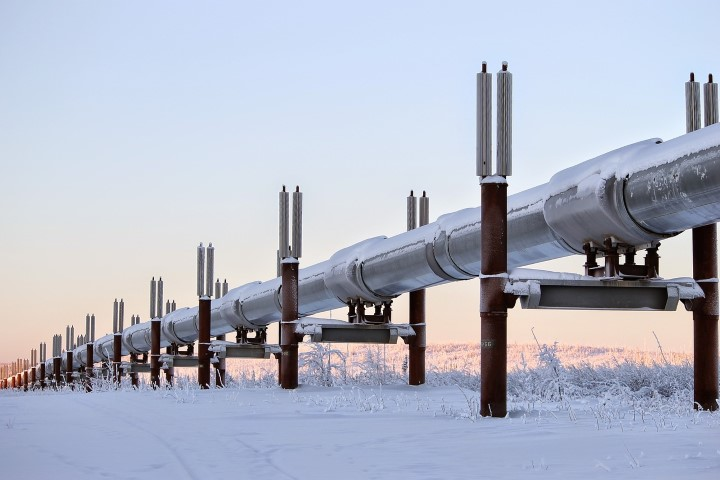

Bild von <a href="https://pixabay.com/de/users/robzor-840419/?utm_source=link-attribution&utm_medium=referral&utm_campaign=image&utm_content=681175">Robson Machado</a> auf <a href="https://pixabay.com/de//?utm_source=link-attribution&utm_medium=referral&utm_campaign=image&utm_content=681175">Pixabay</a>

# 0  | Install & Import
***

In [ ]:
# Install
!uv pip install --system -q keras_tuner

In [ ]:
# Import
from pandas import read_csv, DataFrame, concat

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

import keras
import keras_tuner
from keras_tuner import HyperParameters, RandomSearch
from keras.layers import Dense, Input

from keras.utils import set_random_seed, plot_model

from tensorflow import keras
from tensorflow.config.experimental import enable_op_determinism
import tensorflow as tf

In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings("ignore")

# **1 | Understand**
***


<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

<p><font color='black' size="5">
Anwendungsfall
</font></p>

---



Der Datensatz enthält 9568 Datenpunkte, die von einem Gas- und Dampfturbinenkraftwerk über einen Zeitraum von 6 Jahren (2006-2011) gesammelt wurden, als das Kraftwerk unter Volllast in Betrieb genommen wurde. Die Funktionen bestehen aus den stündlichen durchschnittlichen Umgebungsvariablen
+ Temperatur (T),
+ Umgebungsdruck (AP),
+ Relative Luftfeuchtigkeit (RH)
+ und Abgasvakuum (V),

um die stündliche Netto-Stromerzeugung (EP) der Anlage vorherzusagen.


Ein GuD-Kraftwerk (GuD-Kraftwerk) setzt sich aus Gasturbinen (GT), Dampfturbinen (ST) und Abhitzedampferzeugern zusammen. Bei einem GuD-Kraftwerk wird der Strom durch Gas- und Dampfturbinen erzeugt, die in einem Kreislauf kombiniert werden, und von einer Turbine auf eine andere übertragen. Während das Vakuum von der Dampfturbine beeinflusst wird und sich auf sie auswirkt, beeinflussen die anderen drei Umgebungsvariablen die GT-Leistung.

Der Hochdruckdampf in einem GuD-Kraftwerk wird im sogenannten Abhitzedampferzeuger (AHE) erzeugt – einem zentralen Bauteil, das die Abwärme der Gasturbine nutzt, um Wasser in Dampf umzuwandeln.

Nach der Expansion des Dampfes in der Dampfturbine muss dieser wieder kondensieren, um erneut im Kreislauf genutzt werden zu können. Das passiert im sogenannten Kondensator, einem Wärmeübertrager, in dem der Dampf durch Kühlwasser (z. B. Fluss- oder Meerwasser) abgekühlt wird.

Beim Kondensieren entsteht ein Unterdruck (Vakuum), weil Wasserdampf beim Übergang in den flüssigen Zustand viel Volumen verliert – und das senkt den Druck im Kondensator erheblich, typischerweise auf etwa 0,05 bar oder sogar weniger (je nach Kühlwassertemperatur).

Das Vakuum erhöht die Druckdifferenz über der Dampfturbine, also:

`Druck am Einlass (Hochdruckdampf)−Druck am Auslass (Vakuum)`


Je größer dieser Unterschied ist, desto mehr Energie kann der Dampf beim Expandieren in der Turbine abgeben.

Dadurch:

+ steigt die mechanische Leistung der Dampfturbine,

+ wird mehr Strom im Generator erzeugt,

+ und der Wirkungsgrad des gesamten GuD-Kraftwerks verbessert sich.

[DataSet](http://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant)    
[Info](http://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant)

In [ ]:
df = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/CCPP.csv"
)

In [ ]:
data = df.copy()
target = data.pop("PE")

<p><font color='black' size="5">
EDA (Exploratory Data Analysis) mit Pandas
</font></p>

In [ ]:
data.info()

In [ ]:
data.describe().T

In [ ]:
data.corr()

# 2 |  Prepare

---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Train-Test-Split durchführen</br>
✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features Kodieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>

<p><font color='black' size="5">
Datentyp ermitteln
</font></p>

In [ ]:
all_col = data.columns
num_col = data.select_dtypes(include="number").columns
cat_col = data.select_dtypes(exclude="number").columns

<p><font color='black' size="5">
Skalierung
</font></p>

In [ ]:
scaler = MinMaxScaler()
data[num_col] = scaler.fit_transform(data[num_col])

<p><font color='black' size="5">
Train-Test-Split
</font></p>


In [ ]:
data_train, data_test, target_train, target_test = train_test_split(
    data, target, test_size=0.3, random_state=42
)
data_train.shape, data_test.shape, target_train.shape, target_test.shape

# **3 | Modeling**
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Validiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

<p><font color='black' size="5">
Zufallszahl initialisieren
</font></p>

In [ ]:
set_random_seed(42)
enable_op_determinism()

<p><font size="5">
Modelauswahl
</p>

In [ ]:
# Hyperparameter-Objekt erstellen
hp = HyperParameters()

In [ ]:
# Funktion, um das Keras-Modell mit variablen Hyperparametern zu erstellen - notwendig für die Verwendung des keras-tuners
def build_model(hp):
    model = keras.Sequential()
    model.add(Input(shape=(4,)))  # Definieren des Input-Layers separat

    # Bestimmen der Anzahl der versteckten Schichten
    num_layers = hp.Int("num_layers", min_value=1, max_value=5, step=1)

    # Schleife, um die jeweilige Anzahl von Schichten hinzuzufügen
    for i in range(num_layers):
        model.add(
            Dense(
                units=hp.Int("units_" + str(i), min_value=50, max_value=1000, step=50),
                activation="relu",
            )
        )

    # Output Layer
    model.add(Dense(1))

    # Kompilieren des Modells
    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice("learning_rate", values=[1e-2, 1e-3, 1e-4, 1e-5])
        ),
        loss="mean_absolute_error",
    )
    return model

<p><font size="5">
Hyperparameter Tuning - RandomSearch
</p>

[keras_tuner](https://keras.io/keras_tuner/)

hp.Int: Hierbei wird ein ganzzahliger Hyperparameter mithilfe des hp-Objekts (Hyperparameter) aus KerasTuner definiert.
+ 'units': Dies ist der Name des Hyperparameters. Er bezieht sich  auf die Anzahl der Einheiten in einer neuronalen Netzwerkschicht, was ein gängiger Hyperparameter in maschinellen Lernmodellen ist.
+ min_value=32: Dieser Wert legt den minimal zulässigen Wert für die Anzahl der Einheiten fest, welcher in diesem Fall 32 beträgt.
+ max_value=512: Hiermit wird der maximal zulässige Wert für die Anzahl der Einheiten definiert, welcher hier 512 ist.
+ step=32: Dies definiert die Schrittweite für die Suche nach möglichen Werten.

Die Anzahl der Einheiten kann nur Werte annehmen, die Vielfache von 32 sind, beginnend bei 32 und endend bei 512 (einschließlich). Die möglichen Werte wären also 32, 64, 96, ..., 512.

hp.Choice: Diese Funktion definiert einen Hyperparameter vom Typ "Auswahl".
+ 'learning_rate': Dies ist der Name des Hyperparameters. Er bezieht sich auf die Lernrate, ein wichtiger Hyperparameter in der Optimierung neuronaler Netze. Die Lernrate steuert die Schrittweite, mit der das Modell während des Trainings seine Parameter anpasst.
+ values=[1e-2, 1e-3, 1e-4]: Diese Liste enthält die möglichen Werte, die der Hyperparameter "learning_rate" annehmen kann.

In diesem Fall sind die möglichen Werte 10^-2, 10^-3 und 10^-4.

In [ ]:
# Keras Tuner Initialisierung
tuner = RandomSearch(
    build_model, objective="val_loss", max_trials=5, project_name="keras_tuner"
)

In [ ]:
tuner.search_space_summary()

In [ ]:
# Tuner-Suche starten
tuner.search(data_train, target_train, epochs=10, validation_split=0.2)

In [ ]:
# Die Top 3 Modelle
best_hps_list = tuner.get_best_hyperparameters(num_trials=3)
for i, hps in enumerate(best_hps_list, start=1):
    num_layers = hps.get("num_layers")  # Anzahl der Layer abrufen
    print(f"Bestes Set {i}:")
    print("Layer:", num_layers)

    # Durch jeden Layer iterieren und die zugehörigen 'units' abrufen
    for j in range(num_layers):
        print(f"  Units in Layer {j + 1}:", hps.get(f"units_{j}"))

    print("Lernrate:", hps.get("learning_rate"))
    print("-" * 30)

In [ ]:
# tuner.results_summary()

# 4 | Evaluate
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>

<p><font color='black' size="5">
Prognose auf Basis des besten Modells
</font></p>

In [ ]:
# Laden des besten Modells
best_model = tuner.get_best_models(num_models=1)[0]

In [ ]:
best_model.summary()

In [ ]:
# Verwenden des besten Modells zur Vorhersage
target_pred = best_model.predict(data_test)

<p><font color='black' size="5">
Bestimmtheitsmass
</font></p>

In [ ]:
r2 = r2_score(target_test, target_pred)
print(f"Modell: {best_model} -- Test --- Bestimmtheitsmass: {r2:5.2f}")

<p><font color='black' size="5">
Mean Absolut Error
</font></p>

In [ ]:
mae = mean_absolute_error(target_test, target_pred)
print(f"Modell: {best_model} -- Test -- Mean Absolute Error: {mae:5.2f}")

# 5 | Deploy
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>

# Inhalt aus: `B570-roc-auc-threshold.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
ROC-AUC - Threshold
</b></font> </br></p>

---


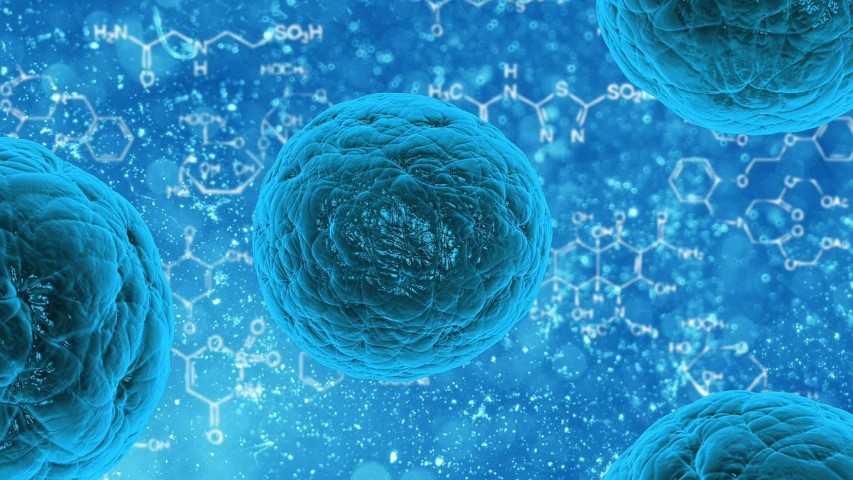

Bild von <a href="https://pixabay.com/de/users/publicdomainpictures-14/?utm_source=link-attribution&utm_medium=referral&utm_campaign=image&utm_content=163711">PublicDomainPictures</a> auf <a href="https://pixabay.com/de//?utm_source=link-attribution&utm_medium=referral&utm_campaign=image&utm_content=163711">Pixabay</a>

# 0  | Install & Import
***

In [ ]:
# Install

In [ ]:
# Import
import numpy as np
from pandas import read_csv, DataFrame

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
    RocCurveDisplay
)

import plotly.express as px
import plotly.subplots as sp
import matplotlib.pyplot as plt

In [ ]:
# Warnung ausstellen
import warnings

warnings.filterwarnings("ignore")

# 1 | Understand
---


<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

<p><font color='black' size="5">
📒 Anwendungsfall
</font></p>




**Beschreibung:**   
Diese Arbeit entstand aus dem Wunsch, Gewebeproben ausschließlich auf der Grundlage einer Feinnadelpunktion (FNA) genau zu diagnostizieren. In Zusammenarbeit mit Prof. Mangasarian und zwei seiner Doktoranden, Rudy Setiono und Kristin Bennett , wurde mithilfe der Multisurface-Methode (MSM) zur Mustertrennung dieser neun Merkmale ein Klassifikator erstellt, der 97 % der neuen Fälle erfolgreich diagnostizierte. Der resultierende Datensatz ist als Wisconsin Breast Cancer Data bekannt.


Die Arbeit an der Bildanalyse begann 1990 mit der Aufnahme von Nick Street in das Forschungsteam. Ziel war es, die Probe anhand eines digitalen Bildes eines kleinen Abschnitts des FNA-Objektträgers zu diagnostizieren.

**Diagnoseablauf:**

Es wird aus dem Gewebe eine FNA entnommen. Dieses Material wird dann auf einen Objektträger montiert und gefärbt, um die Zellkerne hervorzuheben. Ein Teil des Objektträgers, in dem die Zellen gut differenziert sind, wird dann mit einer Digitalkamera und einem Framegrabber-Board gescannt.
Anschließend isoliert der Anwender die einzelnen Zellkerne . Mit einem Mauszeiger zeichnet der Benutzer die ungefähre Grenze jedes Kerns. Mithilfe eines Computer-Vision-Ansatzes, konvergieren diese Annäherungen dann an die genauen nuklearen Grenzen. Sobald alle (oder die meisten) Kerne auf diese Weise isoliert wurden, berechnet das Programm Werte für jedes der zehn Merkmale jedes Kerns und misst Größe, Form und Textur. Der Mittelwert, der Standardfehler und die Extremwerte dieser Merkmale werden berechnet, was zu insgesamt 30 Kernmerkmalen für jede Probe führt.

[DataSet](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original)

[Info](https://pages.cs.wisc.edu/~olvi/uwmp/cancer.html)

**Features:**


+ Dicke: 1 - 10
+ Einheitlichkeit der Zellgröße: 1 - 10
+ Gleichmäßigkeit der Zellform: 1 - 10
+ Randhaftung: 1 - 10
+ Größe einzelner Epithelzellen: 1 - 10
+ Nackte Kerne: 1 - 10
+ Blandes Chromatin: 1 - 1
+ Normale Nukleolen: 1 - 10
+ Mitosen: 1 - 10

**Klassen:**

+ Klasse: (2 für gutartig, 4 für bösartig)

In [ ]:
import pandas as pd
df = read_csv('https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/breast_cancer_wisconsin.csv')

In [ ]:
data = df.copy()
target = data.pop("Class")

# **2 | Prepare**

---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Duplikate ermitteln/löschen</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features Kodieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>
✅ Train-Test-Split durchführen</br>

<p><font color='black' size="5">
Missing Values
</font></p>

In [ ]:
data = data.dropna()

In [ ]:
target = target.loc[data.index]

<p><font color='black' size="5">
UmKodierung
</font></p>

In [ ]:
target.replace([2, 4], [0, 1], inplace=True)  # bösartig → 1

<p><font color='black' size="5">
Train-Test-Split
</font></p>

In [ ]:
from sklearn.model_selection import train_test_split

data_train, data_test, target_train, target_test = train_test_split(
    data, target, test_size=0.20, random_state=42, stratify=target
)
data_train.shape, data_test.shape, target_train.shape, target_test.shape

# **3 | Modeling**
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Validiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

 <p><font color='black' size="5">
Modellauswahl & Training
</font></p>

In [ ]:
model = MLPClassifier(verbose=0, random_state=42)

In [ ]:
model.fit(data_train, target_train)

<p><font color='black' size="5">
Loss-Entwicklung
</font></p>

In [ ]:
title_ = "Loss-Entwicklung"
px.line(
    y=model.loss_curve_,
    title=title_,
    labels={"x": "Epochen", "y": "Loss-Wert"},
    width=800,
    height=400,
)

# 4 | Evaluate
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>

<p><font color='black' size="5">
Prognose
</font></p>

In [ ]:
# Prognose 0/1
target_train_pred = model.predict(data_train)
target_test_pred = model.predict(data_test)

In [ ]:
# Prognose Wahrscheinlichkeiten für 0/1
target_train_proba = model.predict_proba(data_train)
target_test_proba = model.predict_proba(data_test)


<p><font color='black' size="5">
Accuracy
</font></p>

In [ ]:
acc_train = accuracy_score(target_train, target_train_pred) * 100
print(f"Modell: {model} -- Train -- Accuracy: {acc_train:5.2f}")

In [ ]:
acc_test = accuracy_score(target_test, target_test_pred) * 100
print(f"Modell: {model} -- Test -- Accuracy: {acc_test:5.2f}")


<p><font color='black' size="5">
Confusion Matrix
</font></p>

In [ ]:
display_labels = ["Negativ", "Positiv"]
conf_matrix = confusion_matrix(target_test, target_test_pred)
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=display_labels)
disp.plot(cmap="Blues")

In [ ]:
print(classification_report(target_test, target_test_pred, target_names=display_labels))

<p><font color='black' size="5">
ROC-AUC
</font></p>

Die ROC-AUC Analyse ist ein Werkzeug, um beim maschinellen Lernen die Leistung eines Klassifikationsmodells zu bewerten.  

1. **ROC-Kurve (Receiver Operating Characteristic)**: Dies ist ein Graph, der zeigt, wie gut ein Modell zwischen zwei Klassen (zum Beispiel positiv und negativ) unterscheiden kann. Auf der x-Achse wird die Falsch-Positiv-Rate (FPR) abgebildet, und auf der y-Achse die Wahr-Positiv-Rate (TPR). Die FPR zeigt, wie oft das Modell fälschlicherweise eine negative Instanz als positiv klassifiziert, während die TPR zeigt, wie oft das Modell korrekt eine positive Instanz als positiv erkennt.

$$
\text{TPR} = \frac{\text{TP}}{\text{TP} + \text{FN}}
$$
<br>

$$
\text{FPR} = \frac{\text{FP}}{\text{FP} + \text{TN}}
$$
<br>

2. **AUC (Area Under the Curve)**: Dies ist ein Maß dafür, wie gut das Modell insgesamt ist. Es wird durch Berechnung der Fläche unter der ROC-Kurve ermittelt. Ein AUC-Wert von 1,0 bedeutet, dass das Modell perfekt klassifiziert, während ein Wert von 0,5 bedeutet, dass es nicht besser ist als zufälliges Raten.


Die ROC-Kurve wird durch Variation der Schwellwerte für die Entscheidungsgrenze des Modells zwischen 0 und 1 ermittelt.

- **Schwellwert (Threshold)**: Dies ist der Wert, bei dem das Modell entscheidet, ob eine Instanz als positiv oder negativ klassifiziert wird. Indem man den Schwellwert von 0 bis 1 variiert, verändert man, wann das Modell eine Instanz als positiv klassifiziert.

- **Variation der Schwellwerte**: Bei einem niedrigen Schwellwert klassifiziert das Modell mehr Instanzen als positiv, was zu einer höheren Wahr-Positiv-Rate (TPR) und möglicherweise auch zu einer höheren Falsch-Positiv-Rate (FPR) führt. Umgekehrt führt ein höherer Schwellwert dazu, dass das Modell weniger Instanzen als positiv klassifiziert, was die FPR senken kann, aber auch die TPR verringert.

- **Erstellung der ROC-Kurve**: Für jeden Schwellwert wird ein Punkt auf der ROC-Kurve gezeichnet, der aus der FPR und TPR besteht. Die Kurve zeigt, wie sich die TPR und FPR verändern, wenn der Schwellwert variiert wird.


<p><font color='black' size="5">
ROC-AUC Kurve (Yellowbrick)
</font></p>

In [ ]:
from yellowbrick.classifier import ROCAUC

visualizer = ROCAUC(model, micro=False, macro=False, classes=["Negativ", "Positiv"])

visualizer.fit(data_train, target_train)  # Fit the training data to the visualizer
visualizer.score(data_test, target_test)  # Evaluate the model on the test data
visualizer.show()

<p><font color='black' size="5">
ROC-AUC Kurve sklearn
</font></p>

In [ ]:
RocCurveDisplay.from_predictions(
    target_test, target_test_proba[:, 1], name="MLPClassifier"
)
plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Random")

plt.legend()
plt.show()

In [ ]:
rocauc = roc_auc_score(target_train, model.predict_proba(data_train)[:, 1])
print(f"AUC Train: {rocauc:.2f}")

rocauc = roc_auc_score(target_test, model.predict_proba(data_test)[:, 1])
print(f"AUC Test: {rocauc:.2f}")

<p><font color='black' size="5">
Optimaler Schwellenwert
</font></p>

 Der Punkt auf der Kurve, der der linken oberen Ecke am nächsten liegt.

In [ ]:
fpr, tpr, thresholds = roc_curve(target_test, target_test_proba[:, 1])

In [ ]:
# Euklidischen Abstand zu jedem Punkt von der linken oberen Ecke berechnen
distances = np.sqrt((1 - tpr) ** 2 + fpr**2)

# Den Index des minimalen Abstands finden
optimal_idx = np.argmin(distances)

# Den optimalen Schwellenwert finden
optimal_threshold = thresholds[optimal_idx]

print(f"Optimaler Schwellenwert nach Euklidischen Abstand : {optimal_threshold:0.3f}")

In [ ]:
# Manhattan Abstand zu jedem Punkt von der linken oberen Ecke berechnen
manhattan_distances = np.abs(1 - tpr) + np.abs(fpr)

# Den Index des minimalen Abstands finden
optimal_idx = np.argmin(manhattan_distances)

# Den optimalen Schwellenwert finden
optimal_threshold = thresholds[optimal_idx]

print(f"Optimaler Schwellenwert nach Manhatten Abstand: {optimal_threshold:0.3f}")

<p><font color='black' size="5">
Anpassung Schwellwert auf Basis ROC/AUC
</font></p>

In [ ]:
threshold = 0.323  # Distanz: Manhatten und Youden's J-Index
new_target_pred = (target_test_proba[:, 1] >= threshold).astype(int)
conf_matrix = confusion_matrix(target_test, new_target_pred)
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=["No", "Yes"])
disp.plot(cmap="Blues")

In [ ]:
print(classification_report(target_test, new_target_pred, target_names=["No", "Yes"]))

# 5 | Deploy
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>

# Inhalt aus: `B580-validation-learning-curve-titanic.ipynb`
---

<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Supervised Learning - Decision Tree - Titanic
</b></font> </br></p>

---


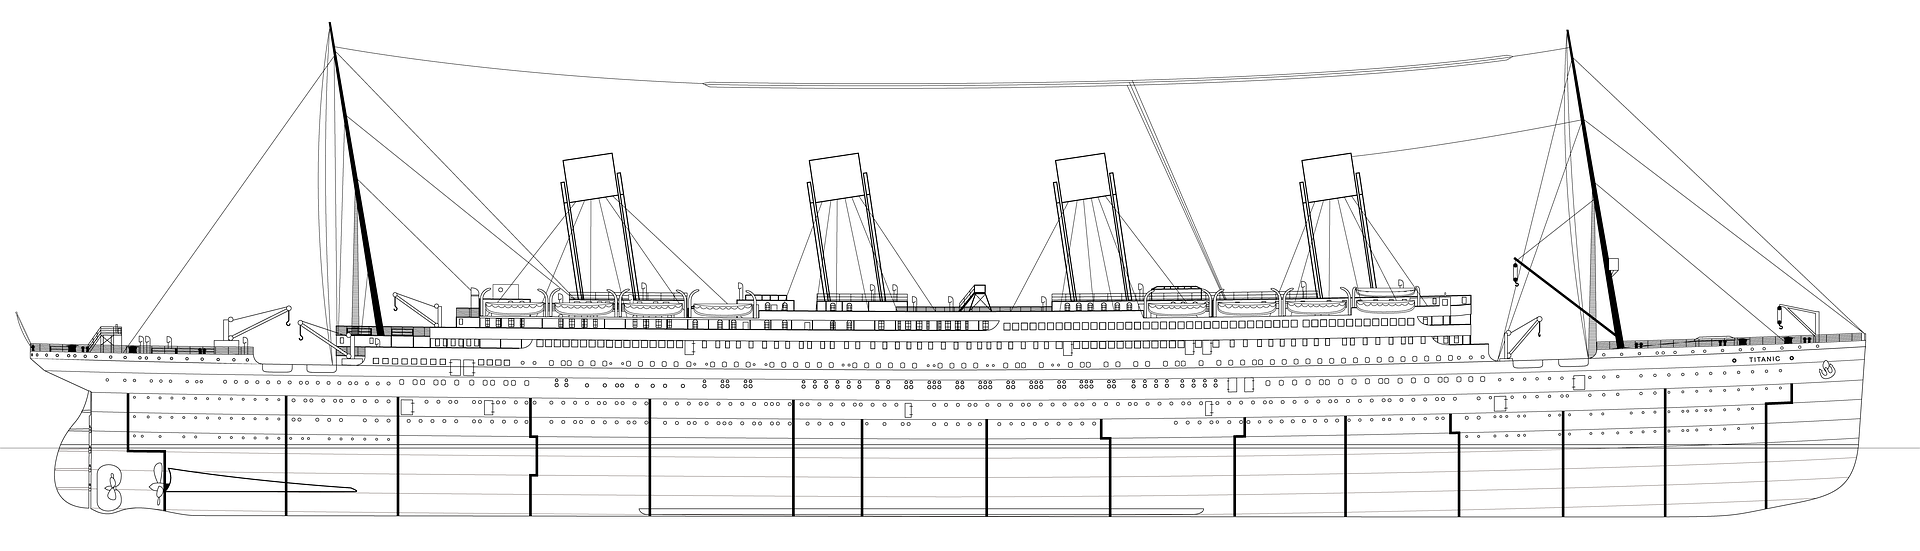

Bild von <a href="https://pixabay.com/de/users/axonia-14892766/?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=6068711">axonia</a> auf <a href="https://pixabay.com/de//?utm_source=link-attribution&amp;utm_medium=referral&amp;utm_campaign=image&amp;utm_content=6068711">Pixabay</a>

# 0  | Install & Import
***

In [ ]:
# Install
!uv pip install --system -q dtreeviz

In [ ]:
# Import
from pandas import read_csv, DataFrame

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, export_graphviz
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

import plotly.express as px
import plotly.subplots as sp

import graphviz
import dtreeviz

from yellowbrick.model_selection import validation_curve, learning_curve

In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings("ignore")

# 1  | Understand
***


<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

<p><font color='black' size="5">
📒 Anwendungsfall
</font></p>

Dies ist der legendäre Titanic ML-Wettbewerb – die beste erste Herausforderung, um in ML-Modellierung einzutauchen.

Die Aufgabe ist einfach: Verwenden Sie maschinelles Lernen, um ein Modell zu erstellen, das vorhersagt, welche Passagiere den Schiffbruch der Titanic überlebt haben.

[Titanic Org](https://www.encyclopedia-titanica.org/)

[DataSet](https://www.openml.org/search?type=data&status=active&id=41265)

[Info](https://www.kaggle.com/competitions/titanic/data)



**Datenfelder:**   
+ Age: Alter
+ Fare: Ticketpreis
+ Sex: Geschlecht (0 = männlich, 1 = weiblich)
+ sibsp: Der Datensatz definiert Familienbeziehungen auf diese Weise ... Geschwister = Bruder, Schwester, Stiefbruder, Stiefschwester Ehepartner = Ehemann, Ehefrau (Geliebte und Verlobte wurden ignoriert)
+ parch: Der Datensatz definiert Familienbeziehungen auf diese Weise ... Elternteil = Mutter, Vater Kind = Tochter, Sohn, Stieftochter, Stiefsohn. Einige Kinder reisten nur mit einem Kindermädchen, daher ist für sie Parch=0
+ Pclass: Passagierklasse, 1.- 3. Klasse
+ Embarked: Hafen der Einschiffung

In [ ]:
df = read_csv(
    "https://raw.githubusercontent.com/ralf-42/ML_Intro/main/02%20data/Titanic.csv",
    usecols=["pclass", "survived", "sex", "age", "sibsp", "parch"],
)

In [ ]:
data = df.copy()
target = data.pop("survived")

<p><font color='black' size="5">
🔎 EDA (Exploratory Data Analysis) mit Pandas
</font></p>

In [ ]:
data.info()

In [ ]:
data.describe().T

In [ ]:
data.groupby("sex").count()

In [ ]:
target.value_counts()

In [ ]:
data[data.age.isnull()].describe().T

# **2 | Prepare**

---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Duplikate ermitteln/löschen</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features Kodieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>
✅ Train-Test-Split durchführen</br>

Kodierung

In [ ]:
data.sex.replace({"male": 0, "female": 1}, inplace=True)

Missing Values

In [ ]:
data.age.fillna(data.age.mean(), inplace=True)

<p><font color='black' size="5">
✂️ Train-Test-Split
</font></p>


In [ ]:
data_train, data_test, target_train, target_test = train_test_split(
    data, target, test_size=0.20, random_state=42, stratify=target
)

In [ ]:
data_train.shape, data_test.shape, target_train.shape, target_test.shape

# **3 | Modeling**
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Validiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

<p><font color='black' size="5">
🏃 Modellauswahl & Training
</font></p>

In [ ]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
model.fit(data_train, target_train)

# 4 | Evaluate
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>

<p><font color='black' size="5">
🔭 Prognose
</font></p>

In [ ]:
target_train_pred = model.predict(data_train)
target_test_pred = model.predict(data_test)

<p><font color='black' size="5">
📱 Confusion Matrix
</font></p>

In [ ]:
conf_matrix = confusion_matrix(target_test, target_test_pred)
display_labels_ = ["Not Survived", "Survived"]
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=display_labels_)
disp.plot(cmap="Blues")

In [ ]:
print(classification_report(target_test, target_test_pred, target_names=display_labels_))

<p><font color='black' size="5">
🎯 Accuracy
</font></p>

In [ ]:
acc_train = accuracy_score(target_train, target_train_pred) * 100
print(f"Modell: {model} -- Train -- Accuracy: {acc_train:5.2f}")

In [ ]:
acc_test = accuracy_score(target_test, target_test_pred) * 100
print(f"Modell: {model} -- Test -- Accuracy: {acc_test:5.2f}%")

<p><font color='black' size="5">
🎲Aufbau Analysewürfel
</font></p>

In [ ]:
# Übernahme der Testdaten
cube = data_test.copy()
cube.reset_index(inplace=True)

In [ ]:
# Übernahme Target real & predict
cube["real"] = DataFrame(target_test.values, columns=["real"])
cube["predict"] = DataFrame(target_test_pred, columns=["predict"])

<p><font color='black' size="5">
📊 Visualisierung real vs predict
</font></p>

In [ ]:
# Histogramm
title_ = "Histogramm real vs predict"
fig = px.histogram(cube, x=["real", "predict"], nbins=2, title=title_)
fig.update_layout(barmode="group", bargap=0.1, width=600, height=600)
fig.show()

<p><font color='black' size="5">
📛 Fehlerhafte Vorhersagen
</font></p>

In [ ]:
# real <> predict
cube[cube.real != cube.predict].describe().T

In [ ]:
cube[cube.real != cube.predict]

<p><font color='black' size="5">
📝 Einzelne Vorhersage
</font></p>

In [ ]:
# 2 neue Datensätze werden zur Prognose an das Modell übergeben: Rose & Jack (Winslet/diCaprio)
new_data = {
    "pclass": [1, 3],
    "sex": [1, 0],
    "age": [22, 23],
    "sibsp": [0, 0],
    "parch": [0, 0],
}
new = DataFrame(new_data)

In [ ]:
# Vorhersage erstellen Rose & Jack
model.predict(new)

<p><font color='black' size="5">
❗Feature Importance
</font></p>

In [ ]:
title_ = "Feature Importance Titanic"
px.bar(
    x=model.feature_importances_, y=data.columns, title=title_, width=800, height=600
).update_yaxes(categoryorder="total ascending")

<p><font color='black' size="5">
✔️  Validation Curve
</font></p>

In [ ]:
viz = validation_curve(
    model,
    data_test,
    target_test,
    param_name="max_depth",
    param_range=range(1, 7),
    cv=4,
    scoring="f1_weighted",
)

<p><font color='black' size="5">
🎓 Learning Curve
</font></p>

In [ ]:
# Clustering: scoring='adjusted_rand_score', Classification: scoring='f1_weighted', 'accuracy', Regression: 'r2'
img = learning_curve(model, data, target, cv=4, scoring="accuracy")

# 5 | Deploy
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>

# Inhalt aus: `B590-automl-pycaret-regression.ipynb`
---

Last updated: 15 Feb 2023

# 👋 PyCaret Regression Tutorial

PyCaret is an open-source, low-code machine learning library in Python that automates machine learning workflows. It is an end-to-end machine learning and model management tool that exponentially speeds up the experiment cycle and makes you more productive.

Compared with the other open-source machine learning libraries, PyCaret is an alternate low-code library that can be used to replace hundreds of lines of code with a few lines only. This makes experiments exponentially fast and efficient. PyCaret is essentially a Python wrapper around several machine learning libraries and frameworks, such as scikit-learn, XGBoost, LightGBM, CatBoost, spaCy, Optuna, Hyperopt, Ray, and a few more.

The design and simplicity of PyCaret are inspired by the emerging role of citizen data scientists, a term first used by Gartner. Citizen Data Scientists are power users who can perform both simple and moderately sophisticated analytical tasks that would previously have required more technical expertise.


# 💻 Installation

PyCaret is tested and supported on the following 64-bit systems:
- Python 3.7 – 3.10
- Python 3.9 for Ubuntu only
- Ubuntu 16.04 or later
- Windows 7 or later

You can install PyCaret with Python's pip package manager:

`pip install pycaret`

PyCaret's default installation will not install all the extra dependencies automatically. For that you will have to install the full version:

`pip install pycaret[full]`

or depending on your use-case you may install one of the following variant:

- `pip install pycaret[analysis]`
- `pip install pycaret[models]`
- `pip install pycaret[tuner]`
- `pip install pycaret[mlops]`
- `pip install pycaret[parallel]`
- `pip install pycaret[test]`

In [1]:
!uv pip install --system -q pycaret[full]

<p><font color='red' size="5"><b>
Laufzeit | Sitzung neu starten!
</font></p>

In [1]:
# check installed version (must be >3.0)
import pycaret
pycaret.__version__

'3.3.2'

# 🚀 Quick start

PyCaret's Regression Module is a supervised machine learning module that is used for estimating the relationships between a dependent variable (often called the outcome variable, or target) and one or more independent variables (often called features, predictors, or covariates).

The objective of regression is to predict continuous values such as predicting sales amount, predicting quantity, predicting temperature, etc. Regression module provides several pre-processing features to preprocess the data for modeling through the setup function.

PyCaret's regression module has many preprocessing capabilities and it coems with over 25 ready-to-use algorithms and several plots to analyze the performance of trained models.

A typical workflow in PyCaret Regression module consist of the following 5 steps in this order:

### **Setup** ➡️ **Compare Models** ➡️ **Analyze Model** ➡️ **Prediction** ➡️ **Save Model**
<br/>

In [2]:
### load sample dataset from pycaret dataset module
from pycaret.datasets import get_data
data = get_data('insurance')

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Setup
The `setup` function initializes the training environment and creates the transformation pipeline. Setup function must be called before executing any other function in PyCaret. It only has two required parameters i.e. `data` and `target`. All the other parameters are optional.

In [ ]:
# import pycaret regression and init setup
from pycaret.regression import *
s = setup(data, target = 'charges', session_id = 123)

Once the setup has been successfully executed it shows the information grid containing experiment level information.

- **Session id:**  A pseudo-random number distributed as a seed in all functions for later reproducibility. If no `session_id` is passed, a random number is automatically generated that is distributed to all functions.<br/>
<br/>
- **Target type:**  Binary, Multiclass, or Regression. The Target type is automatically detected. <br/>
<br/>
- **Original data shape:**  Shape of the original data prior to any transformations. <br/>
<br/>
- **Transformed train set shape :**  Shape of transformed train set <br/>
<br/>
- **Transformed test set shape :**  Shape of transformed test set <br/>
<br/>
- **Numeric features :**  The number of features considered as numerical. <br/>
<br/>
- **Categorical features :**  The number of features considered as categorical. <br/>

PyCaret has two set of API's that you can work with. (1) Functional (as seen above) and (2) Object Oriented API.

With Object Oriented API instead of executing functions directly you will import a class and execute methods of class.

In [ ]:
# import RegressionExperiment and init the class
from pycaret.regression import RegressionExperiment
exp = RegressionExperiment()

In [ ]:
# check the type of exp
type(exp)

In [ ]:
# init setup on exp
exp.setup(data, target = 'charges', session_id = 123)

You can use any of the two method i.e. Functional or OOP and even switch back and forth between two set of API's. The choice of method will not impact the results and has been tested for consistency.
___

## Compare Models

The `compare_models` function trains and evaluates the performance of all the estimators available in the model library using cross-validation. The output of this function is a scoring grid with average cross-validated scores. Metrics evaluated during CV can be accessed using the `get_metrics` function. Custom metrics can be added or removed using `add_metric` and `remove_metric` function.

In [ ]:
# compare baseline models
best = compare_models()

In [ ]:
# compare models using OOP
# exp.compare_models()

In [ ]:
best = create_model('catboost') #choose catboost to avoid plot errors with some models

Notice that the output between functional and OOP API is consistent. Rest of the functions in this notebook will only be shown using functional API only.

___

## Analyze Model

The `plot_model` function is used to analyze the performance of a trained model on the test set. It may require re-training the model in certain cases.

In [ ]:
# plot residuals
plot_model(best, plot = 'residuals')

In [ ]:
# plot error
plot_model(best, plot = 'error')

In [ ]:
# plot feature importance
plot_model(best, plot = 'feature')

In [ ]:
# check docstring to see available plots
# help(plot_model)

An alternate to `plot_model` function is `evaluate_model`. It can only be used in Notebook since it uses `ipywidget`.

In [ ]:
evaluate_model(best)

___

## Prediction
The `predict_model` function returns `prediction_label` as new column to the input dataframe. When data is `None` (default), it uses the test set (created during the setup function) for scoring.

In [ ]:
# predict on test set
holdout_pred = predict_model(best)

In [ ]:
# show predictions df
holdout_pred.head()

The same function works for predicting the labels on unseen dataset. Let's create a copy of original data and drop the `charges`. We can then use the new data frame without labels for scoring.

In [ ]:
# copy data and drop charges

new_data = data.copy()
new_data.drop('charges', axis=1, inplace=True)
new_data.head()

In [ ]:
# predict model on new_data
predictions = predict_model(best, data = new_data)
predictions.head()

___

## Save Model

Finally, you can save the entire pipeline on disk for later use, using pycaret's `save_model` function.

In [ ]:
# save pipeline
save_model(best, 'my_first_pipeline')

In [ ]:
# load pipeline
loaded_best_pipeline = load_model('my_first_pipeline')
loaded_best_pipeline

# 👇 Detailed function-by-function overview

## ✅ Setup
The `setup` function initializes the experiment in PyCaret and creates the transformation pipeline based on all the parameters passed in the function. Setup function must be called before executing any other function. It takes two required parameters: `data` and `target`. All the other parameters are optional and are used for configuring data preprocessing pipeline.

In [ ]:
s = setup(data, target = 'charges', session_id = 123)

To access all the variables created by the setup function such as transformed dataset, random_state, etc. you can use `get_config` method.

In [ ]:
# check all available config
get_config()

In [ ]:
# lets access X_train_transformed
get_config('X_train_transformed')

In [ ]:
# another example: let's access seed
print("The current seed is: {}".format(get_config('seed')))

# now lets change it using set_config
set_config('seed', 786)
print("The new seed is: {}".format(get_config('seed')))

All the preprocessing configurations and experiment settings/parameters are passed into the `setup` function. To see all available parameters, check the docstring:

In [ ]:
# help(setup)

In [ ]:
# init setup with normalize = True
s = setup(data, target = 'charges', session_id = 123,
          normalize = True, normalize_method = 'minmax')

In [ ]:
# lets check the X_train_transformed to see effect of params passed
get_config('X_train_transformed')['age'].hist()

Notice that all the values are between 0 and 1 - that is because we passed `normalize=True` in the `setup` function. If you don't remember how it compares to actual data, no problem - we can also access non-transformed values using `get_config` and then compare. See below and notice the range of values on x-axis and compare it with histogram above.

In [ ]:
get_config('X_train')['age'].hist()

___

## ✅ Compare Models
The `compare_models` function trains and evaluates the performance of all estimators available in the model library using cross-validation. The output of this function is a scoring grid with average cross-validated scores. Metrics evaluated during CV can be accessed using the `get_metrics` function. Custom metrics can be added or removed using `add_metric` and `remove_metric` function.

In [ ]:
best = compare_models()

`compare_models` by default uses all the estimators in model library (all except models with `Turbo=False`) . To see all available models you can use the function `models()`

In [ ]:
# check available models
models()

You can use the `include` and `exclude` parameter in the `compare_models` to train only select model or exclude specific models from training by passing the model id's in `exclude` parameter.

In [ ]:
compare_tree_models = compare_models(include = ['dt', 'rf', 'et', 'gbr', 'xgboost', 'lightgbm', 'catboost'])

In [ ]:
compare_tree_models

The function above has return trained model object as an output. The scoring grid is only displayed and not returned. If you need access to the scoring grid you can use `pull` function to access the dataframe.

In [ ]:
compare_tree_models_results = pull()
compare_tree_models_results

By default `compare_models` return the single best performing model based on the metric defined in the `sort` parameter. Let's change our code to return 3 top models based on `MAE`.

In [ ]:
best_mae_models_top3 = compare_models(sort = 'MAE', n_select = 3)

In [ ]:
# list of top 3 models by MAE
best_mae_models_top3

Some other parameters that you might find very useful in `compare_models` are:

- fold
- cross_validation
- budget_time
- errors
- probability_threshold
- parallel

You can check the docstring of the function for more info.

In [ ]:
# help(compare_models)

## ✅ Experiment Logging
PyCaret integrates with many different type of experiment loggers (default = 'mlflow'). To turn on experiment tracking in PyCaret you can set `log_experiment` and `experiment_name` parameter. It will automatically track all the metrics, hyperparameters, and artifacts based on the defined logger.

In [ ]:
# from pycaret.regression import *
# s = setup(data, target = 'charges', log_experiment='mlflow', experiment_name='insurance_experiment')

In [ ]:
# compare models
# best = compare_models()

In [ ]:
# start mlflow server on localhost:5000
# !mlflow ui

By default PyCaret uses `MLFlow` logger that can be changed using `log_experiment` parameter. Following loggers are available:
    
    - mlflow
    - wandb
    - comet_ml
    - dagshub
    
Other logging related parameters that you may find useful are:

- experiment_custom_tags
- log_plots
- log_data
- log_profile

For more information check out the docstring of the `setup` function.

In [ ]:
# help(setup)

## ✅ Create Model
The `create_model` function trains and evaluates the performance of a given estimator using cross-validation. The output of this function is a scoring grid with CV scores by fold. Metrics evaluated during CV can be accessed using the `get_metrics` function. Custom metrics can be added or removed using `add_metric` and `remove_metric` function. All the available models can be accessed using the `models` function.

In [ ]:
# check all the available models
models()

In [ ]:
# train linear regression with default fold=10
lr = create_model('lr')

The function above has return trained model object as an output. The scoring grid is only displayed and not returned. If you need access to the scoring grid you can use `pull` function to access the dataframe.

In [ ]:
lr_results = pull()
print(type(lr_results))
lr_results

In [ ]:
# train linear regression with fold=3
lr = create_model('lr', fold=3)

In [ ]:
# train linear regression with specific model parameters
create_model('lr', fit_intercept = False)

In [ ]:
# train lr and return train score as well alongwith CV
create_model('lr', return_train_score=True)

Some other parameters that you might find very useful in `create_model` are:

- cross_validation
- engine
- fit_kwargs
- groups

You can check the docstring of the function for more info.

In [ ]:
# help(create_model)

## ✅ Tune Model

The `tune_model` function tunes the hyperparameters of the model. The output of this function is a scoring grid with cross-validated scores by fold. The best model is selected based on the metric defined in optimize parameter. Metrics evaluated during cross-validation can be accessed using the `get_metrics` function. Custom metrics can be added or removed using `add_metric` and `remove_metric` function.

In [ ]:
# train a dt model with default params
dt = create_model('dt')

In [ ]:
# tune hyperparameters of dt
tuned_dt = tune_model(dt)

Metric to optimize can be defined in `optimize` parameter (default = 'Accuracy'). Also, a custom tuned grid can be passed with `custom_grid` parameter.

In [ ]:
dt

In [ ]:
# define tuning grid
dt_grid = {'max_depth' : [None, 2, 4, 6, 8, 10, 12]}

# tune model with custom grid and metric = MAE
tuned_dt = tune_model(dt, custom_grid = dt_grid, optimize = 'MAE')

In [ ]:
# to access the tuner object you can set return_tuner = True
tuned_dt, tuner = tune_model(dt, return_tuner=True)

In [ ]:
# model object
tuned_dt

In [ ]:
# tuner object
tuner

The default search algorithm is `RandomizedSearchCV` from `sklearn`. This can be changed by using `search_library` and `search_algorithm` parameter.

In [ ]:
# tune dt using optuna
tuned_dt = tune_model(dt, search_library = 'optuna')

For more details on all available `search_library` and `search_algorithm` please check the docstring. Some other parameters that you might find very useful in `tune_model` are:

- choose_better
- n_iter
- early_stopping
- groups

You can check the docstring of the function for more info.

In [ ]:
# help(tune_model)

## ✅ Ensemble Model

The `ensemble_model` function ensembles a given estimator. The output of this function is a scoring grid with CV scores by fold. Metrics evaluated during CV can be accessed using the `get_metrics` function. Custom metrics can be added or removed using `add_metric` and `remove_metric` function.

In [ ]:
# ensemble with bagging
ensemble_model(dt, method = 'Bagging')

In [ ]:
# ensemble with boosting
ensemble_model(dt, method = 'Boosting')

Some other parameters that you might find very useful in `ensemble_model` are:

- choose_better
- n_estimators
- groups
- fit_kwargs
- return_train_score

You can check the docstring of the function for more info.

In [ ]:
# help(ensemble_model)

## ✅ Blend Models

The `blend_models` function trains a `VotingRegressor` for select models passed in the `estimator_list` parameter. The output of this function is a scoring grid with CV scores by fold. Metrics evaluated during CV can be accessed using the `get_metrics` function. Custom metrics can be added or removed using `add_metric` and `remove_metric` function.

In [ ]:
# top 3 models based on mae
best_mae_models_top3

In [ ]:
# blend top 3 models
blend_models(best_mae_models_top3)

Some other parameters that you might find very useful in `blend_models` are:

- choose_better
- weights
- optimize
- fit_kwargs
- return_train_score

You can check the docstring of the function for more info.

In [ ]:
# help(blend_models)

## ✅ Stack Models

The `stack_models` function trains a meta-model over select estimators passed in the estimator_list parameter. The output of this function is a scoring grid with CV scores by fold. Metrics evaluated during CV can be accessed using the `get_metrics` function. Custom metrics can be added or removed using `add_metric` and `remove_metric` function.

In [ ]:
# stack models
stack_models(best_mae_models_top3)

Some other parameters that you might find very useful in `stack_models` are:

- choose_better
- meta_model
- restack
- optimize
- return_train_score

You can check the docstring of the function for more info.

In [ ]:
# help(stack_models)

## ✅ Plot Model

The `plot_model` function analyzes the performance of a trained model on the hold-out set. It may require re-training the model in certain cases.

In [ ]:
# plot residuals
plot_model(best, plot = 'residuals')

In [ ]:
# to control the scale of plot
plot_model(best, plot = 'residuals', scale = 2)

In [ ]:
# to save the plot
plot_model(best, plot = 'residuals', save=True)

Some other parameters that you might find very useful in `plot_model` are:

- fit_kwargs
- plot_kwargs
- groups
- display_format

You can check the docstring of the function for more info.

In [ ]:
# help(plot_model)

## ✅ Interpret Model

The `interpret_model` function analyzes the predictions generated from a trained model. Most plots in this function are implemented based on the SHAP (Shapley Additive exPlanations). For more info on this, please see https://shap.readthedocs.io/en/latest/

In [ ]:
# train lightgbm model
lightgbm = create_model('lightgbm')

In [ ]:
# interpret summary model
interpret_model(lightgbm, plot = 'summary')

In [ ]:
# reason plot for test set observation 1
interpret_model(lightgbm, plot = 'reason', observation = 1)

Some other parameters that you might find very useful in `interpret_model` are:

- plot
- feature
- use_train_data
- X_new_sample
- y_new_sample
- save

You can check the docstring of the function for more info.

In [ ]:
# help(interpret_model)

## ✅ Get Leaderboard

This function returns the leaderboard of all models trained in the current setup.

In [ ]:
# get leaderboard
lb = get_leaderboard()
lb

In [ ]:
# select the best model based on MAE
lb.sort_values(by='MAE', ascending=True)['Model'].iloc[0]

Some other parameters that you might find very useful in `get_leaderboard` are:

- finalize_models
- fit_kwargs
- model_only
- groups

You can check the docstring of the function for more info.

In [ ]:
# help(get_leaderboard)

## ✅ AutoML
This function returns the best model out of all trained models in the current setup based on the optimize parameter. Metrics evaluated can be accessed using the `get_metrics` function.

In [ ]:
# find best model based on CV metrics
automl()

## ✅ Dashboard
The dashboard function generates the interactive dashboard for a trained model. The dashboard is implemented using `ExplainerDashboard`. For more information check out [Explainer Dashboard.](explainerdashboard.readthedocs.io)

In [ ]:
# dashboard function
dashboard(dt, display_format ='inline')

## ✅Create App
This function creates a basic gradio app for inference.

In [ ]:
# create gradio app
create_app(best)

## ✅ Create API
This function takes an input model and creates a POST API for inference.

In [ ]:
# create api
create_api(best, api_name = 'my_first_api')

In [ ]:
# !python my_first_api.py

In [ ]:
# check out the .py file created with this magic command
# %load my_first_api.py

## ✅ Create Docker
This function creates a `Dockerfile` and `requirements.txt` for productionalizing API end-point.

In [ ]:
create_docker('my_first_api')

In [ ]:
# check out the DockerFile file created with this magic command
# %load DockerFile

In [ ]:
# check out the requirements file created with this magic command
# %load requirements.txt

## ✅ Finalize Model
This function trains a given model on the entire dataset including the hold-out set.

In [ ]:
final_best = finalize_model(best)

In [ ]:
final_best

## ✅ Convert Model
This function transpiles the trained machine learning model's decision function in different programming languages such as Python, C, Java, Go, C#, etc. It is very useful if you want to deploy models into environments where you can't install your normal Python stack to support model inference.

In [ ]:
# transpiles learned function to java
print(convert_model(dt, language = 'java'))

## ✅ Deploy Model
This function deploys the entire ML pipeline on the cloud.

**AWS:**  When deploying model on AWS S3, environment variables must be configured using the command-line interface. To configure AWS environment variables, type `aws configure` in terminal. The following information is required which can be generated using the Identity and Access Management (IAM) portal of your amazon console account:

- AWS Access Key ID
- AWS Secret Key Access
- Default Region Name (can be seen under Global settings on your AWS console)
- Default output format (must be left blank)

**GCP:** To deploy a model on Google Cloud Platform ('gcp'), the project must be created using the command-line or GCP console. Once the project is created, you must create a service account and download the service account key as a JSON file to set environment variables in your local environment. Learn more about it: https://cloud.google.com/docs/authentication/production

**Azure:** To deploy a model on Microsoft Azure ('azure'), environment variables for the connection string must be set in your local environment. Go to settings of storage account on Azure portal to access the connection string required.
AZURE_STORAGE_CONNECTION_STRING (required as environment variable)
Learn more about it: https://docs.microsoft.com/en-us/azure/storage/blobs/storage-quickstart-blobs-python?toc=%2Fpython%2Fazure%2FTOC.json

In [ ]:
# deploy model on aws s3
# deploy_model(best, model_name = 'my_first_platform_on_aws',
#             platform = 'aws', authentication = {'bucket' : 'pycaret-test'})

In [ ]:
# load model from aws s3
# loaded_from_aws = load_model(model_name = 'my_first_platform_on_aws', platform = 'aws',
#                              authentication = {'bucket' : 'pycaret-test'})

# loaded_from_aws

## ✅ Save / Load Model
This function saves the transformation pipeline and a trained model object into the current working directory as a pickle file for later use.

In [ ]:
# save model
save_model(best, 'my_first_model')

In [ ]:
# load model
loaded_from_disk = load_model('my_first_model')
loaded_from_disk

## ✅ Save / Load Experiment
This function saves all the experiment variables on disk, allowing to later resume without rerunning the setup function.

In [ ]:
# save experiment
save_experiment('my_experiment')

In [ ]:
# load experiment from disk
exp_from_disk = load_experiment('my_experiment', data=data)

# Inhalt aus: `template.ipynb`
---

#  0 | Install & Import

In [ ]:
# Install


In [ ]:
# Import


In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings('ignore')

#  1 | Understand

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

#  2 | Prepare

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Duplikate ermitteln/löschen</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features Kodieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>
✅ Train-Test-Split durchführen</br>

#  3 | Modeling

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Validiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

#  4 | Evaluate

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>

#  5 | Deploy

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>